C:\Users\vitth\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Logistic Regression Accuracy: 92.89 %
Random Forest Accuracy: 98.48 %

Confusion Matrix (Random Forest):
[[143   1]
 [  2  51]]

Classification Report (Random Forest):
              precision    recall  f1-score   support

         0.0       0.99      0.99      0.99       144
         1.0       0.98      0.96      0.97        53

    accuracy                           0.98       197
   macro avg       0.98      0.98      0.98       197
weighted avg       0.98      0.98      0.98       197


Cross Validation Accuracy: 98.37 %

Top 10 Important Features:
Age                                  0.146651
Cost                                 0.130599
Condition_Heart Disease              0.110335
Procedure_Cardiac Catheterization    0.079605
Satisfaction                         0.077528
Gender_Male                          0.074421
Condition_Heart Attack               0.062393
Age_Group_Adult                      0.038933
High_Cost                            0.028002
Condition_Fractured Arm    

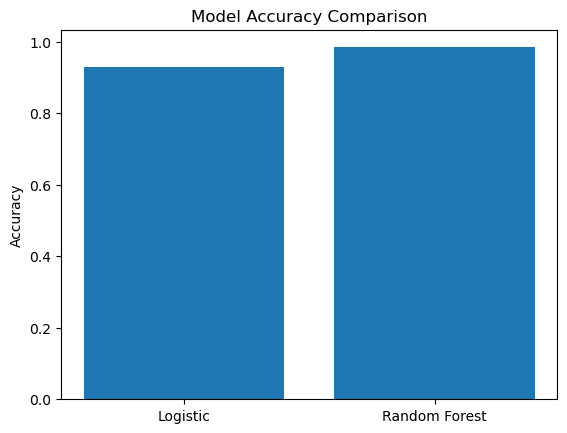

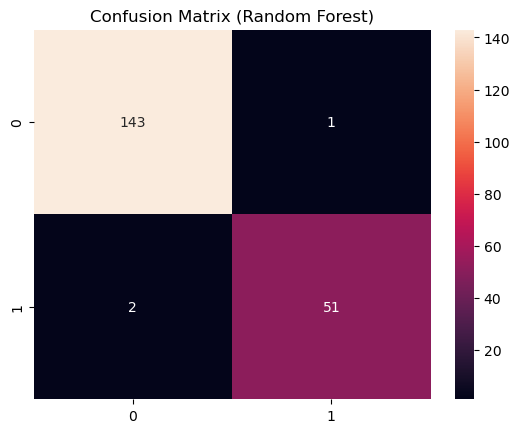

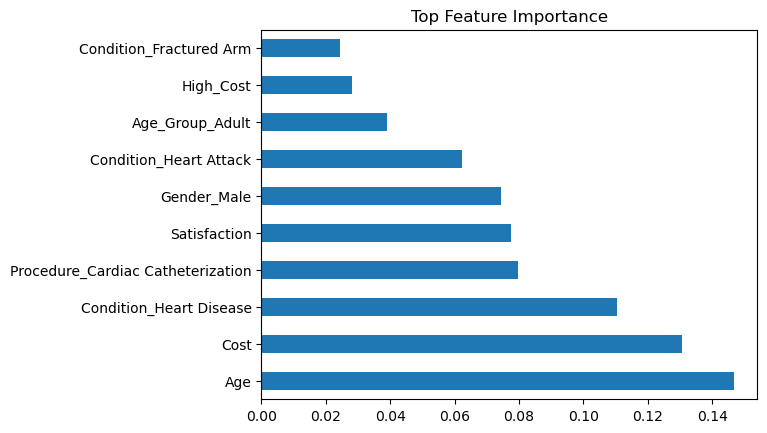

In [17]:
# =====================================
# 1. IMPORT LIBRARIES
# =====================================
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# =====================================
# 2. LOAD DATA
# =====================================
df = pd.read_csv("../data/hospital data analysis.csv")

# =====================================
# 3. DATA CLEANING
# =====================================
df['Condition'] = df['Condition'].fillna(df['Condition'].mode()[0])
df['Procedure'] = df['Procedure'].fillna(df['Procedure'].mode()[0])

df['Cost'] = df['Cost'].fillna(df['Cost'].mean())
df['Length_of_Stay'] = df['Length_of_Stay'].fillna(df['Length_of_Stay'].mean())

# Fix Readmission values
df['Readmission'] = df['Readmission'].str.strip().str.capitalize()

# =====================================
# 4. FEATURE ENGINEERING
# =====================================
df['Readmission_Flag'] = df['Readmission'].map({'Yes': 1, 'No': 0})

# Remove null target
df = df.dropna(subset=['Readmission_Flag'])

df['Age_Group'] = pd.cut(df['Age'],
                         bins=[0, 30, 50, 100],
                         labels=['Young', 'Adult', 'Senior'])

df['High_Cost'] = df['Cost'] > 10000

df['Stay_Type'] = df['Length_of_Stay'].apply(
    lambda x: 'Short' if x <= 3 else 'Medium' if x <= 7 else 'Long'
)

# =====================================
# 5. ENCODING
# =====================================
df_model = pd.get_dummies(df, drop_first=True)

# =====================================
# 6. REMOVE DATA LEAKAGE
# =====================================
cols_to_drop = [col for col in df_model.columns if 'Readmission' in col]
X = df_model.drop(cols_to_drop, axis=1)
y = df_model['Readmission_Flag']

# =====================================
# 7. TRAIN-TEST SPLIT (STRATIFIED)
# =====================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# =====================================
# 8. LOGISTIC REGRESSION
# =====================================
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)

# =====================================
# 9. RANDOM FOREST (CONTROL OVERFITTING)
# =====================================
rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=5,
    random_state=42
)

rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

# =====================================
# 10. EVALUATION
# =====================================
lr_acc = accuracy_score(y_test, lr_pred)
rf_acc = accuracy_score(y_test, rf_pred)

print("Logistic Regression Accuracy:", round(lr_acc*100, 2), "%")
print("Random Forest Accuracy:", round(rf_acc*100, 2), "%")

print("\nConfusion Matrix (Random Forest):")
print(confusion_matrix(y_test, rf_pred))

print("\nClassification Report (Random Forest):")
print(classification_report(y_test, rf_pred))

# =====================================
# 11. CROSS VALIDATION (VERY IMPORTANT)
# =====================================
cv_scores = cross_val_score(rf, X, y, cv=5)

print("\nCross Validation Accuracy:", round(cv_scores.mean()*100, 2), "%")

# =====================================
# 12. FEATURE IMPORTANCE
# =====================================
importance = pd.Series(rf.feature_importances_, index=X.columns)
importance = importance.sort_values(ascending=False)

print("\nTop 10 Important Features:")
print(importance.head(10))

# =====================================
# 13. VISUALIZATION
# =====================================

# Accuracy comparison
plt.figure()
plt.bar(['Logistic', 'Random Forest'], [lr_acc, rf_acc])
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.show()

# Confusion matrix heatmap
plt.figure()
sns.heatmap(confusion_matrix(y_test, rf_pred), annot=True, fmt='d')
plt.title("Confusion Matrix (Random Forest)")
plt.show()

# Feature importance plot
importance.head(10).plot(kind='barh')
plt.title("Top Feature Importance")
plt.show()

In [23]:
X = df_model.drop(cols_to_drop, axis=1)

In [25]:
model_columns = X.columns

In [27]:
new_patient = pd.DataFrame({
    'Age': [65],
    'Cost': [15000],
    'Length_of_Stay': [6],
    'Satisfaction': [3],
    'High_Cost': [True],
    'Gender': ['Male'],
    'Condition': ['Heart Disease'],
    'Procedure': ['Cardiac Catheterization'],
    'Age_Group': ['Senior'],
    'Stay_Type': ['Medium']
})

In [29]:
new_patient = pd.get_dummies(new_patient)

In [31]:
new_patient = new_patient.reindex(columns=model_columns, fill_value=0)

In [33]:
prediction = rf.predict(new_patient)
print(prediction)

[1.]
